Importing plotly failed. Interactive plots will not work.
17:04:41 - cmdstanpy - INFO - Chain [1] start processing
17:04:41 - cmdstanpy - INFO - Chain [1] done processing


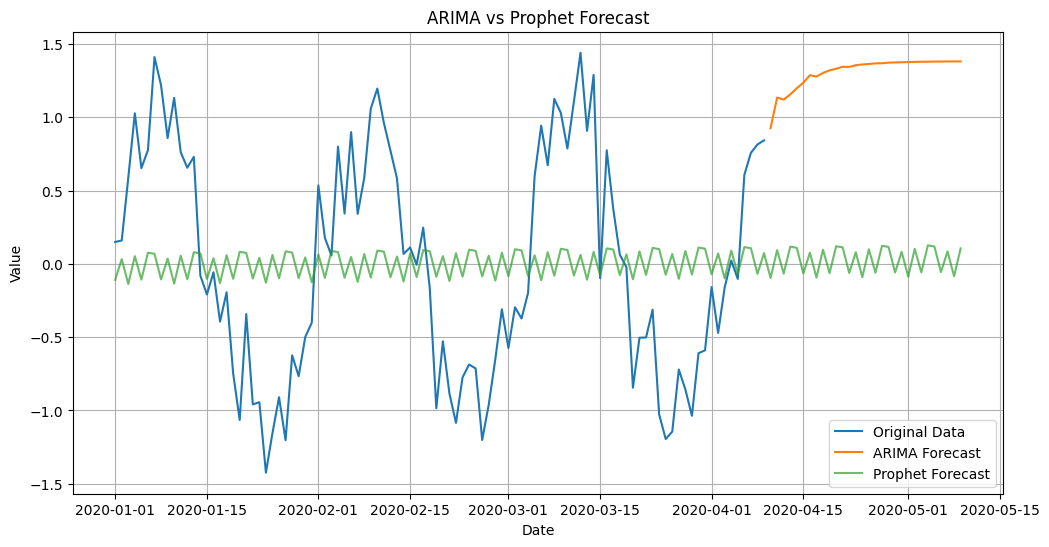

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# -----------------------------
# 1. Generate sample time series data
# -----------------------------
np.random.seed(42)
date_rng = pd.date_range(start='2020-01-01', periods=100, freq='D')
data = pd.DataFrame({
    'ds': date_rng,
    'y': np.sin(np.linspace(0, 20, 100)) + np.random.normal(0, 0.3, 100)
})

# -----------------------------
# 2. ARIMA Forecast
# -----------------------------
try:
    arima_model = ARIMA(data['y'], order=(5, 1, 0))  # (p,d,q)
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(steps=30)
except Exception as e:
    print(f"ARIMA error: {e}")
    arima_forecast = pd.Series()

# -----------------------------
# 3. Prophet Forecast
# -----------------------------
try:
    prophet_model = Prophet(daily_seasonality=True)
    prophet_model.fit(data)
    future = prophet_model.make_future_dataframe(periods=30)
    prophet_forecast = prophet_model.predict(future)
except Exception as e:
    print(f"Prophet error: {e}")
    prophet_forecast = pd.DataFrame()

# -----------------------------
# 4. Plot results
# -----------------------------
plt.figure(figsize=(12, 6))

# Original data
plt.plot(data['ds'], data['y'], label='Original Data')

# ARIMA forecast
if not arima_forecast.empty:
    plt.plot(pd.date_range(data['ds'].iloc[-1] + pd.Timedelta(days=1), periods=30, freq='D'),
             arima_forecast, label='ARIMA Forecast')

# Prophet forecast
if not prophet_forecast.empty:
    plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', alpha=0.7)

plt.legend()
plt.title("ARIMA vs Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()


/tmp/ipykernel_83/2294710903.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='2020-01-01', periods=50, freq='M')
/srv/conda/envs/notebook/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/srv/conda/envs/notebook/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


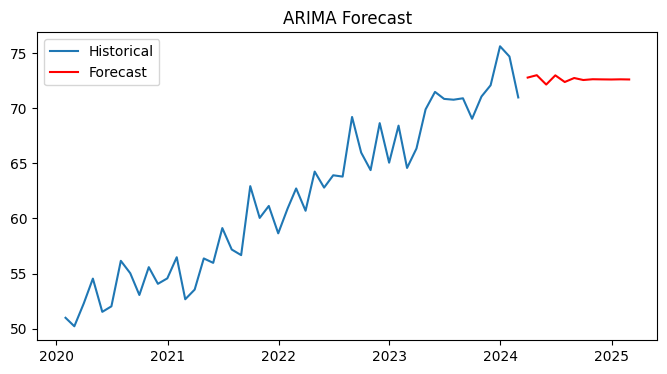

In [2]:
# ARIMA Example
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Generate synthetic time series data
np.random.seed(42)
time = pd.date_range(start='2020-01-01', periods=50, freq='M')
data = pd.Series(50 + np.arange(50) * 0.5 + np.random.normal(scale=2, size=50), index=time)

# Fit ARIMA model (p=2, d=1, q=2 as example)
model = ARIMA(data, order=(2, 1, 2))
model_fit = model.fit()

# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(data, label='Historical')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title("ARIMA Forecast")
plt.legend()
plt.show()


/tmp/ipykernel_83/2628024056.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='2020-01-01', periods=50, freq='M')
17:07:58 - cmdstanpy - INFO - Chain [1] start processing
17:07:58 - cmdstanpy - INFO - Chain [1] done processing
/srv/conda/envs/notebook/lib/python3.10/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


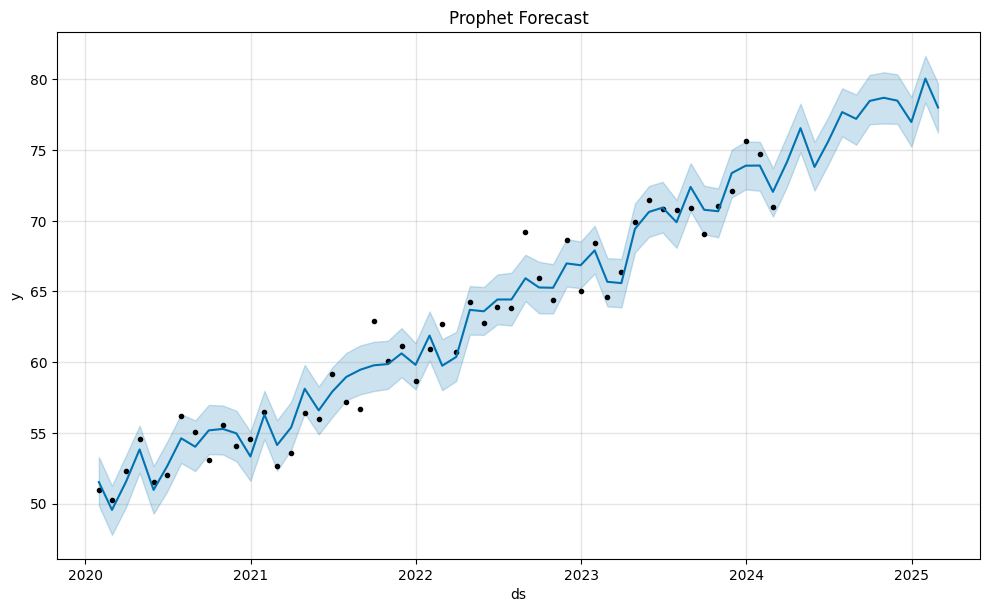

In [3]:
# Prophet Example
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet  # pip install prophet

# Generate synthetic time series data
np.random.seed(42)
time = pd.date_range(start='2020-01-01', periods=50, freq='M')
values = 50 + np.arange(50) * 0.5 + np.random.normal(scale=2, size=50)

# Prepare DataFrame for Prophet
df = pd.DataFrame({'ds': time, 'y': values})

# Fit Prophet model
model = Prophet()
model.fit(df)

# Create future dataframe for 12 months ahead
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()
